# Full 3D Pose Estimation Pipeline
This notebook combines 2D pose detection and 3D reconstruction steps.

In [ ]:
import os
import numpy as np
from tqdm import tqdm
from ultralytics import YOLO
import pickle
from scipy.optimize import least_squares, minimize
import torch

from helpers.predictors import *
from helpers.json_handling import read_keypoints_mmpose
from helpers.camera import *
from helpers.definitions import *
from helpers.plotting import *
from helpers.pose_construction import *
from helpers.hand_transform import *
from helpers.triangulation import *
from helpers.hand_optimization import *
from helpers.sequence_optimization import optimize_sequence
from helpers.video_processing import *
from helpers.hand_detection import *
from helpers.pose_visualization import *
from helpers.weakloss import BMCLoss
import helpers.definitions

# Configuration
data_collection = 'cha/cha6'  # Change this to match your data collection
show = True  # Show visualizations
resolution = (960, 540)  # Processing resolution
original_resolution = (3840, 2160)  # Original video resolution
max_hands = 2  # Maximum number of hands to track per person
reproj_threshold = 7.5

# Optimization Configs
adjust_hands = False  # Adjust hands based on body poses
use_canonical = True
only_seq = False
only_nobmc = True
outlier_detection = False

FORCE_RETRAIN = False  # Force rerunning of optimization

# Camera configuration
far_field_cameras = []  # Specify which cameras to use
near_field_cameras = []  # Specify which cameras to use
for i in range(1, 13):
    if i < 5:
        far_field_cameras.append('gopro' + str(i))
    else:
        near_field_cameras.append('gopro' + str(i))


# Ensure the correct cameras are set up
for camera in far_field_cameras + near_field_cameras:
    if camera not in cam_names:
        print(f"Camera {camera} not found in cam_names, adding it.")
        helpers.definitions.cam_names.append(camera)

for camera in cam_names:
    if camera not in far_field_cameras and camera not in near_field_cameras:
        print(f"Camera {camera} is not assigned to any category, remvoving it.")
        cam_names.remove(camera)


Device: cuda
Torch compile enabled: True


## Initialize Models
Initialize all required models for detection and pose estimation.

In [2]:
# Initialize YOLO models for hand detection
model_person = YOLO('checkpoints/yolo/yolo11l.pt')
model_hand = YOLO('checkpoints/yolo/rohan_pretrained.pt')

# Configure model settings
model_hand.conf = 0.3  # NMS confidence threshold
model_hand.iou = 0.3   # NMS IoU threshold

# Initialize models with TAM tracker
USE_TAM = True
initialize_models(use_tam=USE_TAM, use_wholebody=True)

# Set up paths
data_dir = f'inputs/{data_collection}'  # Input video directory
pose_output_dir = f'pose_outputs/{data_collection}'  # 2D pose output directory
output_3d_dir = f'output_3d/{data_collection}'  # 3D pose output directory
detection_dir = f'outputs/{data_collection}'  # Directory containing detection txt files

os.makedirs(pose_output_dir, exist_ok=True)
os.makedirs(output_3d_dir, exist_ok=True)

Loads checkpoint by local backend from path: checkpoints/hands/detection/cascade_rcnn_x101_64x4d_fpn_20e_onehand10k-dac19597_20201030.pth
Loads checkpoint by local backend from path: checkpoints/body/detection/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
Disable torch compile due to unsupported GPU.
Loads checkpoint by local backend from path: checkpoints/hands/pose/rtmpose-m_simcc-hand5_pt-aic-coco_210e-256x256-74fb594_20230320.pth
Loads checkpoint by local backend from path: checkpoints/body/pose/rtmpose-x_simcc-body7_pt-body7-halpe26_700e-384x288-7fb6e239_20230606.pth
Loads checkpoint by local backend from path: checkpoints/wholebody/rtmpose-l_simcc-coco-wholebody_pt-aic-coco_270e-384x288-eaeb96c8_20230125.pth
RTMPose wholebody model initialized


c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmpose.visualization.local_visualizer.PoseLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Models initialized with EfficientTAM tracker
Pose estimation models initialized
RTMPose wholebody model ready
YOLO models initialized


## Process Videos and Extract 2D Poses

In [3]:
# Process all videos
for video_file in os.listdir(data_dir):
    if video_file.endswith('.MP4'):
        video_name = os.path.splitext(video_file)[0]
        # Check if video is from an allowed camera
        if any(video_name.startswith(cam + '_') for cam in far_field_cameras + near_field_cameras):
            # Process the video
            total_frames = process_single_video_wholebody(video_name, data_dir, pose_output_dir, show=show, vis_output_dir=pose_output_dir)
        else:
            print(f"Skipping {video_name} - not in far field cameras list")

Processing gopro10_synced_cut with wholebody model...
Skipping gopro10_synced_cut - already processed
Processing gopro11_synced_cut with wholebody model...
Skipping gopro11_synced_cut - already processed
Processing gopro12_synced_cut with wholebody model...
Skipping gopro12_synced_cut - already processed
Processing gopro1_synced_cut with wholebody model...
Skipping gopro1_synced_cut - already processed
Processing gopro2_synced_cut with wholebody model...
Skipping gopro2_synced_cut - already processed
Processing gopro3_synced_cut with wholebody model...
Skipping gopro3_synced_cut - already processed
Processing gopro4_synced_cut with wholebody model...
Skipping gopro4_synced_cut - already processed
Processing gopro5_synced_cut with wholebody model...
Skipping gopro5_synced_cut - already processed
Processing gopro6_synced_cut with wholebody model...
Skipping gopro6_synced_cut - already processed
Processing gopro7_synced_cut with wholebody model...
Skipping gopro7_synced_cut - already proc

## Reconstruct 3D Poses
Load 2D poses and camera parameters, then reconstruct 3D poses.

In [4]:
# Load camera parameters
camera_params_dir = f'camera_poses/{data_collection.split("/")[0]}'
output_file = os.path.join(output_3d_dir, 'poses_3d.npz')

camera_intrinsics, camera_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join(camera_params_dir, 'camera_intrinsics'),
    os.path.join(camera_params_dir, 'camera_extrinsics/aligned_poses.json'),
    suffix='_synced',
    named=True,
    import_extrinsics_matrix=True
)

far_field_cam_intr = [camera_intrinsics[cam] for cam in far_field_cameras]
far_field_cam_extr = [camera_extrinsics[cam] for cam in far_field_cameras]
far_field_cam_dist = [distortion_coeffs[cam] for cam in far_field_cameras]
far_field_cam_mat = [camera_matrices[cam] for cam in far_field_cameras]

if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'poses_3d.npz')):
    print(f"Found existing body pose estimations, loading from {output_file}...")
    # Save results
    pose_file = np.load(output_file)
    poses_2d_body = pose_file['poses_2d']
    poses_3d_body = pose_file['poses_3d']
else:

    # Read 2D keypoints from JSON files
    poses_2d_body, poses_2d_hands = read_keypoints_mmpose(
        pose_output_dir, 
        cam_names, 
        num_frames=total_frames,  # Use dynamically determined frame count
        num_body_keypoints=17,  # Number of keypoints for body
        num_hand_keypoints=21,  # Number of keypoints for hands
        suffix='_synced_cut',
        use_wholebody=True
    )

    # Mask keypoints based on confidence
    poses_2d_masked = mask_keypoints(
        poses_2d_body, 
        confidence_threshold=0.3, 
        min_cameras=2, 
        num_keypoints=17
    )

    # Reconstruct 3D poses
    poses_3d_body = reconstruct_3d_pose(
        poses_2d_masked,
        far_field_cam_intr,
        far_field_cam_extr,
        far_field_cam_dist,
        far_field_cam_mat,
        regularization_weight=1.0,
        reprojection_weight=1.0,
        smoothing=True
    )

    # Save results
    np.savez(
        output_file,
        poses_2d=poses_2d_body,
        poses_3d=poses_3d_body
    )

# Visualize results
if show and not os.path.exists(os.path.join(output_3d_dir, 'visualization.mp4')):
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization',
        xlim=(1, -1),
        ylim=(1, -1),
        zlim=(0, 2.5),
        use_wholebody=True
    )

Found existing body pose estimations, loading from output_3d/cha/cha5\poses_3d.npz...


## Hand Detection and Tracking
Using pre-trained YOLO models for person and hand detection, followed by hand pose estimation and tracking. The system first detects persons using YOLOv8, then searches for hands within detected person regions using a specialized hand detection model.

In [5]:
# Process all videos in the inputs folder
for video_file in os.listdir(data_dir):
    if video_file.endswith('.MP4'):
        video_name = os.path.splitext(video_file)[0]
        if any(video_name.startswith(cam) for cam in near_field_cameras):
            print(f"\nProcessing video: {video_name}")
            video_path = os.path.join(data_dir, video_file)

            if os.path.exists(f"outputs/{data_collection}/{video_name}.txt"):
                print("Output already exists, skipping")
                continue
            # Process the video
            #bboxes = process_video_rohan(video_path, model_person, model_hand, show=show)
            bboxes = process_video_wholebody_hands(video_name, data_dir=data_dir, pose_dir=pose_output_dir, save_dir=detection_dir, show=show)
            
            if len(bboxes) == 0:
                print("No hands detected")
            else:
                (boxes, conf, frame_idxs) = zip(*bboxes)
                print(f"\nFound hands at frame {frame_idxs}")
                print(f"Bounding boxes: \n{boxes}")

                os.makedirs(f"outputs/{data_collection}", exist_ok=True)
                save_to_file(bboxes, f"outputs/{data_collection}/{video_name}.txt")


Processing video: gopro10_synced_cut
Output already exists, skipping

Processing video: gopro11_synced_cut
Output already exists, skipping

Processing video: gopro12_synced_cut
Output already exists, skipping

Processing video: gopro5_synced_cut
Output already exists, skipping

Processing video: gopro6_synced_cut
Output already exists, skipping

Processing video: gopro7_synced_cut
Output already exists, skipping

Processing video: gopro8_synced_cut
Output already exists, skipping

Processing video: gopro9_synced_cut
Output already exists, skipping


## Hand Tracking with EfficientTAM
This section handles hand tracking using the EfficientTAM algorithm. The process first detects people and hands using YOLO models, then uses EfficientTAM to track detected hands through video sequences. This enables robust hand tracking even with rapid movements and partial occlusions.

In [6]:
# Process near field cameras for hand poses
hand_poses_2d = {}
output_file = os.path.join(output_3d_dir, 'hand_poses_2d.npz')
if os.path.exists(output_file):
    print("Hand poses already found, skipping")
    hand_poses_2d = np.load(output_file, allow_pickle=True)['poses_2d'].item()
    
else:
    output_dir_temp = os.path.join(output_3d_dir, 'hand_poses_2d_temp')
    os.makedirs(output_dir_temp, exist_ok=True)

    for video_file in sorted(os.listdir(data_dir), key=lambda x: int(x.split('gopro')[1].split('_')[0]) if 'gopro' in x else 0, reverse=True):
        if video_file.endswith('.MP4'):
            video_name = os.path.splitext(video_file)[0]
            if any(video_name.startswith(cam) for cam in near_field_cameras):
                cam_name = video_name.split('_')[0]
                print(f"\nProcessing {video_name} for hand detection and tracking...")
                video_path = os.path.join(data_dir, video_file)
                
                if os.path.exists(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl")):
                    print(f"Tracks already found for {video_name}")

                    with open(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl"), 'rb') as f:
                        tracks = pickle.load(f)

                else:
                    # Track hands
                    tracks, frame_names = process_video_wholebody_hands_for_tracking(
                        video_name, 
                        data_dir, 
                        detection_dir, 
                        resolution, 
                        original_resolution, 
                        max_hands, 
                        show=show,
                        add_object_fn=add_object,
                        track_object_fn=track_object
                    )

                    if tracks is not None:
                        # Save tracked boxes
                        with open(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl"), 'wb') as f:
                            tracks = adjust_tracks(tracks, resolution, original_resolution)
                            pickle.dump(tracks, f)
                
                if tracks is not None: 
                    if os.path.exists(os.path.join(output_dir_temp, cam_name + '.npy')):
                        print(f"Hand poses already processed for {video_name}, skipping")
                        hand_poses_2d[cam_name] = np.load(os.path.join(output_dir_temp, cam_name + '.npy'), allow_pickle=True)
                        
                    else:
                        # Process and visualize poses
                        hand_poses_2d[cam_name] = process_and_visualize_poses(
                            video_path, 
                            tracks, 
                            pose_output_dir,
                            poses_3d_body,
                            camera_matrices,
                            camera_intrinsics,
                            camera_extrinsics,
                            distortion_coeffs,
                            hide_legs=True,
                            create_label_poses=True
                        )

                        np.save(os.path.join(output_dir_temp, cam_name), hand_poses_2d[cam_name], allow_pickle=True)
                        print(f"Processed {video_name} for hand poses.")

                

    # Save hand poses to file
    np.savez(
        output_file,
        poses_2d=hand_poses_2d,
    )

Hand poses already found, skipping


## Hand Pose Reconstruction Methods

This notebook supports four different approaches for reconstructing 3D hand poses from 2D observations:

1. **BMC-based Optimization (Original Method)**: Uses a biomechanically constrained (BMC) loss function to optimize hand poses, along with weighted reprojection error and temporal consistency

2. **Weighted Triangulation**: Reconstructs hand poses using weighted triangulation similar to the body keypoint reconstruction, using keypoint confidence scores as weights

3. **Optimization without BMC**: Optimizes hand poses using only weighted reprojection error and temporal consistency, without biomechanical constraints

4. **Sequence Optimization**: Optimizes the entire sequence at once using LBFGS to maintain better temporal consistency across frames

Each method builds upon the same initial hand poses, which are created by applying canonical hand poses to the wrist positions from the body model.

## Hand-ID Matching using Wholebody Pose Estimation

This section implements a function to match tracked hand object IDs with their correct hand sides (left/right) based on wholebody pose estimation. The function compares tracked hands with wholebody hands or canonical hand projections to determine consistent ID mapping across the video sequence.

In [7]:
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_id_mapping.pkl')):
    print("Hand ID mapping already exists, loading...")
    with open(os.path.join(output_3d_dir, 'hand_id_mapping.pkl'), 'rb') as f:
        hand_id_mapping = pickle.load(f)
else:
    print("Identifying hand IDs...")

    # Prepare video paths dictionary for the identify_hand_ids function
    video_paths = {}
    for cam_name in hand_poses_2d.keys():
        video_paths[cam_name] = os.path.join(data_dir, f"{cam_name}_synced_cut.MP4")

    # Run hand ID identification
    hand_id_mapping = identify_hand_ids(
        hand_poses_2d,
        video_paths,
        camera_intrinsics,
        camera_extrinsics,
        distortion_coeffs,
        poses_3d_body,
        num_frames=300,  # Process first 30 frames (adjust as needed)
        visualize=True,  # Set to True to see visual matches
        pose_output_dir=pose_output_dir
    )

    # Save the hand ID mapping
    with open(os.path.join(output_3d_dir, 'hand_id_mapping.pkl'), 'wb') as f:
        pickle.dump(hand_id_mapping, f)

# Update the hand tracking and optimization functions to use this mapping
print("\nHand ID mapping:")
for cam_name, mapping in hand_id_mapping.items():
    print(f"Camera {cam_name}:")
    for obj_id, hand_side in mapping.items():
        print(f"  Object ID {obj_id} -> {'Left' if hand_side == 0 else 'Right'} hand")

Hand ID mapping already exists, loading...

Hand ID mapping:
Camera gopro12:
  Object ID 1 -> Right hand
  Object ID 0 -> Left hand
Camera gopro11:
  Object ID 1 -> Right hand
Camera gopro10:
  Object ID 0 -> Right hand
Camera gopro9:
  Object ID 1 -> Right hand
  Object ID 0 -> Right hand
Camera gopro8:
  Object ID 0 -> Right hand
  Object ID 1 -> Left hand
Camera gopro7:
  Object ID 0 -> Left hand
  Object ID 1 -> Right hand
Camera gopro6:
  Object ID 1 -> Left hand
  Object ID 0 -> Right hand
Camera gopro5:


In [8]:
from pykalman import KalmanFilter
import numpy as np

def detect_outliers(poses_3d, threshold=0.01, poses_2d=None, camera_params=None):
    """
    Detect outliers in 3D poses using bidirectional distance checks, Kalman filtering, 
    and optionally reprojection error for 2D poses.

    Args:
        poses_3d (np.ndarray): 3D poses for outlier detection (frames x keypoints x 3).
        threshold (float): Distance threshold for outlier detection (in meters).
        poses_2d (dict, optional): 2D poses for reprojection error calculation.
        camera_params (dict, optional): Camera parameters for reprojection.

    Returns:
        np.ndarray: Boolean array indicating outliers (True = outlier).
        np.ndarray: Smoothed 3D poses after Kalman filtering.
    """
    num_frames, num_keypoints, _ = poses_3d.shape
    outliers = np.zeros((num_frames, num_keypoints), dtype=bool)

    # Initialize Kalman filter for smoothing
    kf = KalmanFilter(initial_state_mean=np.zeros(3), n_dim_obs=3)
    kf = kf.em(poses_3d.reshape(-1, 3), n_iter=10)  # Train on the data

    # Apply Kalman filter to smooth poses
    smoothed_poses = []
    for keypoint_idx in range(num_keypoints):
        keypoint_trajectory = poses_3d[:, keypoint_idx, :]
        valid_mask = ~np.isnan(keypoint_trajectory).any(axis=1)
        if np.sum(valid_mask) < 3:  # Skip if insufficient valid data
            smoothed_poses.append(keypoint_trajectory)
            continue

        # Smooth valid keypoints
        smoothed_keypoints = np.full_like(keypoint_trajectory, np.nan)
        smoothed_keypoints[valid_mask] = kf.smooth(keypoint_trajectory[valid_mask])[0]
        smoothed_poses.append(smoothed_keypoints)

    smoothed_poses = np.stack(smoothed_poses, axis=1)

    # Bidirectional distance-based outlier detection
    for frame_idx in range(1, num_frames - 1):
        for keypoint_idx in range(num_keypoints):
            if np.isnan(poses_3d[frame_idx, keypoint_idx]).any():
                outliers[frame_idx, keypoint_idx] = True
                continue

            # Compute distances to neighboring frames
            prev_dist = np.linalg.norm(
                smoothed_poses[frame_idx, keypoint_idx] - smoothed_poses[frame_idx - 1, keypoint_idx]
            )
            next_dist = np.linalg.norm(
                smoothed_poses[frame_idx, keypoint_idx] - smoothed_poses[frame_idx + 1, keypoint_idx]
            )

            # Mark as outlier if distance exceeds threshold
            if prev_dist > threshold or next_dist > threshold:
                outliers[frame_idx, keypoint_idx] = True

    # Reprojection error-based outlier detection (if 2D poses are provided)
    if poses_2d is not None and camera_params is not None:
        for cam_name, cam_poses_2d in poses_2d.items():
            for frame_idx, pose_2d in cam_poses_2d.items():
                if frame_idx >= num_frames:
                    continue

                # Project 3D poses to 2D
                reprojected_pose = project_points(
                    smoothed_poses[frame_idx], camera_params[cam_name]
                )
                reprojection_error = np.linalg.norm(pose_2d - reprojected_pose, axis=1)

                # Mark as outlier if reprojection error exceeds threshold
                outliers[frame_idx] |= reprojection_error > threshold

    # Replace outliers with NaN in smoothed poses
    smoothed_poses[outliers] = np.nan

    return outliers, smoothed_poses

Triangulated hand poses already found with mapping, skipping
Initial Loss (no BMC):
Reprojection loss: 60.331146240234375
Temporal loss: 0.0
Shape loss: 0.0
Wrist loss: 0.0
Total loss: 60.331146240234375
Final loss (no BMC):
Reprojection loss: 13.0741548538208
Temporal loss: 0.0
Shape loss: 0.0
Wrist loss: 1.532330315967556e-05
Total loss: 13.074920654296875
Initial Loss (no BMC):
Reprojection loss: 113.1249008178711
Temporal loss: 0.0
Shape loss: 0.0
Wrist loss: 0.0
Total loss: 113.1249008178711
Final loss (no BMC):
Reprojection loss: 12.9639310836792
Temporal loss: 0.0
Shape loss: 0.0
Wrist loss: 0.00022440330940298736
Total loss: 12.975151062011719
Initial Loss (no BMC):
Reprojection loss: 46.452823638916016
Temporal loss: 0.0
Shape loss: 0.0
Wrist loss: 0.0
Total loss: 46.452823638916016
Final loss (no BMC):
Reprojection loss: 7.113432884216309
Temporal loss: 0.0
Shape loss: 0.0
Wrist loss: 9.002883598441258e-05
Total loss: 7.117934226989746
Initial Loss (no BMC):
Reprojection loss

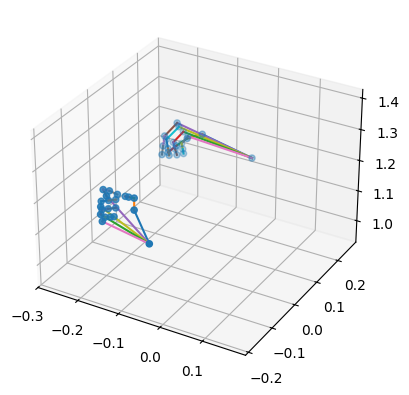

In [9]:
from scipy.signal import savgol_filter


# Use the hand_id_mapping in match_hand_poses function by adding the mapping parameter
# This will ensure hands are correctly matched during optimization process

# Method 1: Triangulation method with hand ID mapping
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz')):
    print("Triangulated hand poses already found with mapping, skipping")
    smoothed_triangulated_hands = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz'))['poses_3d']

elif not only_seq and not only_nobmc:
    triangulated_hand_poses_3d_with_mapping = []
    for frame_idx in range(len(poses_3d_body)):
        # Triangulate hand keypoints for this frame with ID mapping
        hand_3d = triangulate_hand_keypoints(
            hand_poses_2d,
            camera_intrinsics,
            camera_extrinsics,
            camera_matrices,
            distortion_coeffs,
            frame_idx,
            hand_id_mapping=hand_id_mapping  # Use the mapping here
        )
        triangulated_hand_poses_3d_with_mapping.append(hand_3d)
        print(f"Triangulated hand pose with mapping for frame {frame_idx}: {hand_3d.shape}")

    triangulated_hand_poses_3d_with_mapping = np.array(triangulated_hand_poses_3d_with_mapping)

    print(triangulated_hand_poses_3d_with_mapping.shape)

    triangulated_hand_poses_3d_with_mapping = interpolate_keypoints(triangulated_hand_poses_3d_with_mapping)

    # Apply temporal smoothing to reduce jitter
    smoothed_triangulated_hands = savgol_filter(triangulated_hand_poses_3d_with_mapping, 
                                            window_length=15,  # Must be odd and <= num_frames
                                            polyorder=3,
                                            axis=0)

    # Save results for triangulation with mapping
    output_file_triangulation_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_triangulation_mapped.npz')
    np.savez(
        output_file_triangulation_mapped,
        poses_3d=smoothed_triangulated_hands,
    )

# Method 2: No-BMC Optimization with hand ID mapping
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz')):
    print("No-BMC optimized hand poses already found with mapping, skipping")
    nobmc_optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz'))['poses_3d']

elif not only_seq:
    nobmc_optimized_hand_poses_3d = []
    not_initialized = True
    initial_frame_idx = 0
    while not_initialized and initial_frame_idx < len(poses_3d_body):
        # For first frame, use initial hand poses
        initial_pose = np.concatenate([
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[initial_frame_idx], side='left'),
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[initial_frame_idx], side='right')
        ])
        
        # Optimize without BMC but with hand ID mapping
        optimized_hand, loss = optimize_poses_no_bmc(
            initial_pose, hand_poses_2d,
            camera_intrinsics, camera_extrinsics, distortion_coeffs,
            frame_idx=initial_frame_idx, hand_id_mapping=hand_id_mapping,
            lambdas=[1.0, 20.0, 50.0, 50.0], body_pose=poses_3d_body[initial_frame_idx]
        )
        if loss <= reproj_threshold:
            not_initialized = False
            nobmc_optimized_hand_poses_3d.append(optimized_hand)
            prev_optimized_hand = optimized_hand
            print(f"Found initializing frame: {initial_frame_idx}")
        else:
            initial_frame_idx += 1
            nobmc_optimized_hand_poses_3d.append(None)
    if initial_frame_idx > 0:
        for frame_idx in range(initial_frame_idx-1, -1, -1):
            if adjust_hands:
                # Initialize hands based on previous optimized pose
                left_hand = initialize_hand_pose_for_next_frame(
                    prev_optimized_hand[:num_keypoints_hands], 
                    poses_3d_body[frame_idx], 
                    poses_3d_body[frame_idx+1], 
                    side='left'
                )
                right_hand = initialize_hand_pose_for_next_frame(
                    prev_optimized_hand[num_keypoints_hands:], 
                    poses_3d_body[frame_idx], 
                    poses_3d_body[frame_idx+1], 
                    side='right'
                )
            elif use_canonical:
                left_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
                right_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')

            else:
                left_hand = prev_optimized_hand[:num_keypoints_hands]
                right_hand = prev_optimized_hand[num_keypoints_hands:]

            # Concatenate left and right hand poses
            initial_pose = np.concatenate([left_hand, right_hand])
            
            # If the previous optimized hand is NaN, use the initial pose
            if np.isnan(prev_optimized_hand).any():
                print(f"Previous optimized hand for frame {frame_idx} is NaN, using initial pose")
                prev_optimized_hand = initial_pose

            # Optimize without BMC but with hand ID mapping
            optimized_hand, loss = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs,
                frame_idx=frame_idx, previous_pose=prev_optimized_hand,
                hand_id_mapping=hand_id_mapping,
                lambdas=[1.0, 20.0, 50.0, 50.0], body_pose=poses_3d_body[frame_idx]
            )
            nobmc_optimized_hand_poses_3d[frame_idx] = optimized_hand
            prev_optimized_hand = optimized_hand
                
            print(f"No-BMC optimized hand pose with mapping for frame {frame_idx}: {optimized_hand.shape}")

    for frame_idx in range(initial_frame_idx+1, len(poses_3d_body)):
        if adjust_hands:
            # Initialize hands based on previous optimized pose
            left_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[:num_keypoints_hands], 
                poses_3d_body[frame_idx], 
                poses_3d_body[frame_idx-1], 
                side='left'
            )
            right_hand = initialize_hand_pose_for_next_frame(
                prev_optimized_hand[num_keypoints_hands:], 
                poses_3d_body[frame_idx], 
                poses_3d_body[frame_idx-1], 
                side='right'
            )
        elif use_canonical:
            left_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
            right_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')

        else:
            left_hand = prev_optimized_hand[:num_keypoints_hands]
            right_hand = prev_optimized_hand[num_keypoints_hands:]

        # Concatenate left and right hand poses
        initial_pose = np.concatenate([left_hand, right_hand])
        
        # If the previous optimized hand is NaN, use the initial pose
        if np.isnan(prev_optimized_hand).any():
            print(f"Previous optimized hand for frame {frame_idx} is NaN, using initial pose")
            prev_optimized_hand = initial_pose

        # Optimize without BMC but with hand ID mapping
        optimized_hand, loss = optimize_poses_no_bmc(
            initial_pose, hand_poses_2d,
            camera_intrinsics, camera_extrinsics, distortion_coeffs,
            frame_idx=frame_idx, previous_pose=prev_optimized_hand,
            hand_id_mapping=hand_id_mapping,
            lambdas=[1.0, 20.0, 50.0, 50.0], body_pose=poses_3d_body[frame_idx]
        )
        nobmc_optimized_hand_poses_3d.append(optimized_hand)
        prev_optimized_hand = optimized_hand
            
        print(f"No-BMC optimized hand pose with mapping for frame {frame_idx}: {optimized_hand.shape}")

    nobmc_optimized_hand_poses_3d = np.array(nobmc_optimized_hand_poses_3d)

    # Save results for No-BMC optimization with mapping
    output_file_nobmc_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped.npz')
    np.savez(
        output_file_nobmc_mapped,
        poses_3d=nobmc_optimized_hand_poses_3d,
    )

if outlier_detection:
    outliers, nobmc_optimized_hand_poses_3d = detect_outliers(nobmc_optimized_hand_poses_3d)
    if np.any(outliers):
        print("Outliers detected in No-BMC optimized hand poses")
        nobmc_optimized_hand_poses_3d[outliers] = np.nan  # Replace outliers with NaN

    nobmc_optimized_hand_poses_3d = interpolate_keypoints(nobmc_optimized_hand_poses_3d)
    print("Applied outlier detection and smoothing to No-BMC optimized hand poses")
    output_file_nobmc_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_no_bmc_mapped_outliers.npz')
    np.savez(
        output_file_nobmc_mapped,
        poses_3d=nobmc_optimized_hand_poses_3d,
    )

# Method 3: BMC-based Optimization
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz')):
    print("Hand poses already found with mapping, skipping")
    optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz'))['poses_3d']
elif not only_seq and not only_nobmc:
    optimized_hand_poses_3d = []
    for frame_idx in range(len(poses_3d_body)):
        if frame_idx == 0:
            initial_pose = np.concatenate([
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
            ])
            print(f"Initial pose for frame {frame_idx}: {initial_pose}")
            
            # Optimize hand poses with ID mapping
            optimized_hand = optimize_poses(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs, 
                frame_idx=frame_idx, visualize=False, input_dir=data_dir,
                hand_id_mapping=hand_id_mapping
            )
            optimized_hand_poses_3d.append(optimized_hand)
            prev_optimized_hand = optimized_hand
        else:

            if adjust_hands:
                # Initialize hands based on previous optimized pose
                left_hand = initialize_hand_pose_for_next_frame(
                    prev_optimized_hand[:num_keypoints_hands], 
                    poses_3d_body[frame_idx], 
                    poses_3d_body[frame_idx-1], 
                    side='left'
                )
                right_hand = initialize_hand_pose_for_next_frame(
                    prev_optimized_hand[num_keypoints_hands:], 
                    poses_3d_body[frame_idx], 
                    poses_3d_body[frame_idx-1], 
                    side='right'
                )
            elif use_canonical:
                left_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
                right_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')

            else:
                left_hand = prev_optimized_hand[:num_keypoints_hands]
                right_hand = prev_optimized_hand[num_keypoints_hands:]
            initial_pose = np.concatenate([left_hand, right_hand])
            # Optimize subsequent frames with ID mapping
            optimized_hand = optimize_poses(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs, 
                frame_idx=frame_idx, previous_pose=prev_optimized_hand,
                visualize=False, input_dir=data_dir,
                hand_id_mapping=hand_id_mapping
            )
            if np.isnan(optimized_hand).any():
                optimized_hand_poses_3d.append(prev_optimized_hand)
            else:
                optimized_hand_poses_3d.append(optimized_hand)
                prev_optimized_hand = optimized_hand
        
        print(f"Optimized hand pose with mapping for frame {frame_idx}: {optimized_hand.shape}")

    # Convert to numpy array
    optimized_hand_poses_3d = np.array(optimized_hand_poses_3d)

    # Save results with correct mapping
    output_file_bmc_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_bmc_mapped.npz')
    np.savez(
        output_file_bmc_mapped,
        poses_3d=optimized_hand_poses_3d,
    )

# Method 4: Sequence Optimization with hand ID mapping (No-BMC)
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_sequence_mapped.npz')):
    print("Sequence-optimized hand poses already found with mapping, skipping")
    sequence_optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_sequence_mapped.npz'))['poses_3d']
elif not only_nobmc:
    # Create initial poses based on canonical hand poses
    initial_sequence = []
    for frame_idx in range(len(poses_3d_body)):
        initial_pose = np.concatenate([
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
        ])
        initial_sequence.append(initial_pose)
        if np.isnan(initial_pose).any():
            print(f"Initial pose for frame {frame_idx} contains NaN values")
            print(poses_3d_body[frame_idx][6], poses_3d_body[frame_idx][8], poses_3d_body[frame_idx][10])
            print(poses_3d_body[frame_idx][5], poses_3d_body[frame_idx][7], poses_3d_body[frame_idx][9])
    initial_sequence = np.array(initial_sequence)

    
    # Interpolate missing keypoints
    initial_sequence = interpolate_keypoints(initial_sequence)
    
    # Apply sequence optimization
    print("Starting sequence optimization...")
    sequence_optimized_hand_poses_3d = optimize_sequence(
        initial_sequence,
        hand_poses_2d,
        camera_intrinsics,
        camera_extrinsics,
        distortion_coeffs,
        poses_3d_body,
        hand_id_mapping=hand_id_mapping,
        use_bmc=False,  # Can be set to True to use BMC constraints
        lambdas=[1.0, 20.0, 20.0, 0.0, 5.0]  # [reprojection, temporal, spatial, bmc, shape]
    )
    
    # Save results with correct mapping
    output_file_sequence_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_sequence_mapped.npz')
    np.savez(
        output_file_sequence_mapped,
        poses_3d=sequence_optimized_hand_poses_3d,
    )

# Method 5: Sequence Optimization with hand ID mapping (BMC)
if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_sequence_bmc_mapped.npz')):
    print("Sequence-optimized hand poses already found with mapping, skipping")
    sequence_bmc_optimized_hand_poses_3d = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_sequence_bmc_mapped.npz'))['poses_3d']
elif not only_seq and not only_nobmc:
    # Create initial poses based on canonical hand poses
    initial_sequence = []
    for frame_idx in range(len(poses_3d_body)):
        initial_pose = np.concatenate([
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
        ])
        initial_sequence.append(initial_pose)
        if np.isnan(initial_pose).any():
            print(f"Initial pose for frame {frame_idx} contains NaN values")
            print(poses_3d_body[frame_idx][6], poses_3d_body[frame_idx][8], poses_3d_body[frame_idx][10])
            print(poses_3d_body[frame_idx][5], poses_3d_body[frame_idx][7], poses_3d_body[frame_idx][9])
    initial_sequence = np.array(initial_sequence)

    
    # Interpolate missing keypoints
    initial_sequence = interpolate_keypoints(initial_sequence)
    
    # Apply sequence optimization
    print("Starting sequence optimization...")
    sequence_bmc_optimized_hand_poses_3d = optimize_sequence(
        initial_sequence,
        hand_poses_2d,
        camera_intrinsics,
        camera_extrinsics,
        distortion_coeffs,
        poses_3d_body,
        hand_id_mapping=hand_id_mapping,
        use_bmc=True,  # Can be set to True to use BMC constraints
        lambdas=[1.0, 20.0, 20.0, 3.0, 5.0]  # [reprojection, temporal, spatial, bmc, shape]
    )
    
    # Save results with correct mapping
    output_file_sequence_bmc_mapped = os.path.join(output_3d_dir, 'hand_poses_3d_sequence_bmc_mapped.npz')
    np.savez(
        output_file_sequence_bmc_mapped,
        poses_3d=sequence_bmc_optimized_hand_poses_3d,
    )

if not only_nobmc and not only_seq and not os.path.exists(os.path.join(output_3d_dir, 'visualization_triangulated_hands_mapped.mp4')):
    # Visualize all four methods with correct mapping
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_triangulated_hands_mapped',
        smoothed_triangulated_hands,
        render_body=False,
        dynamic_limits=True
    )

    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_nobmc_hands_mapped',
        nobmc_optimized_hand_poses_3d,
        render_body=False,
        dynamic_limits=True
    )

    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_bmc_hands_mapped',
        optimized_hand_poses_3d,
        render_body=False,
        dynamic_limits=True
    )

    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_sequence_hands_mapped',
        sequence_optimized_hand_poses_3d,
        render_body=False,
        dynamic_limits=True
    )
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_sequence_bmc_hands_mapped',
        sequence_bmc_optimized_hand_poses_3d,
        render_body=False,
        dynamic_limits=True
    )

elif only_seq and not os.path.exists(os.path.join(output_3d_dir, 'visualization_sequence_hands_mapped.mp4')):
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_sequence_hands_mapped',
        sequence_optimized_hand_poses_3d,
        render_body=False,
        dynamic_limits=True
    )
elif only_nobmc and not os.path.exists(os.path.join(output_3d_dir, 'visualization_nobmc_hands_mapped.mp4')):
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_nobmc_hands_mapped',
        nobmc_optimized_hand_poses_3d,
        render_body=False,
        dynamic_limits=True
    )

hand_poses_methods_mapped = {}
# Create a dictionary of all hand pose methods with mapping for comparison
if only_nobmc:
    hand_poses_methods_mapped['No-BMC_Optimization'] = nobmc_optimized_hand_poses_3d
elif only_seq:
    hand_poses_methods_mapped['Sequence_Optimization'] = sequence_optimized_hand_poses_3d
else:
    hand_poses_methods_mapped = {
        'Triangulation': smoothed_triangulated_hands,
        'No-BMC_Optimization': nobmc_optimized_hand_poses_3d,
        'BMC_Optimization': optimized_hand_poses_3d,
        'Sequence_Optimization': sequence_optimized_hand_poses_3d
    }

# Create reprojection videos comparing the mapped methods
if not os.path.exists(os.path.join(output_3d_dir, 'comparisons')):
    create_reprojection_videos(
        poses_3d_body,
        hand_poses_methods_mapped,
        camera_intrinsics,
        camera_extrinsics,
        distortion_coeffs,
        data_dir,
        os.path.join(output_3d_dir, 'comparisons'),
        camera_angles=["gopro7"],  # Specify which cameras to use
        hide_legs=True
    )

# Example usage with viewpoint comparison
# create_reprojection_videos(
#     poses_3d_body,
#     hand_poses_methods_mapped,  # Dictionary of hand pose methods
#     camera_intrinsics,
#     camera_extrinsics,
#     distortion_coeffs,
#     data_dir,    
#     os.path.join(output_3d_dir, 'viewpoint_comparisons'),
#     camera_angles=['gopro10', 'gopro8', 'gopro7'],  # Specify which cameras to use
#     hide_legs=True,
#     compare_viewpoints=True,  # Enable viewpoint comparison mode
#     hand_id_mapping=hand_id_mapping  # Pass the hand ID mapping for viewpoint counts
# )

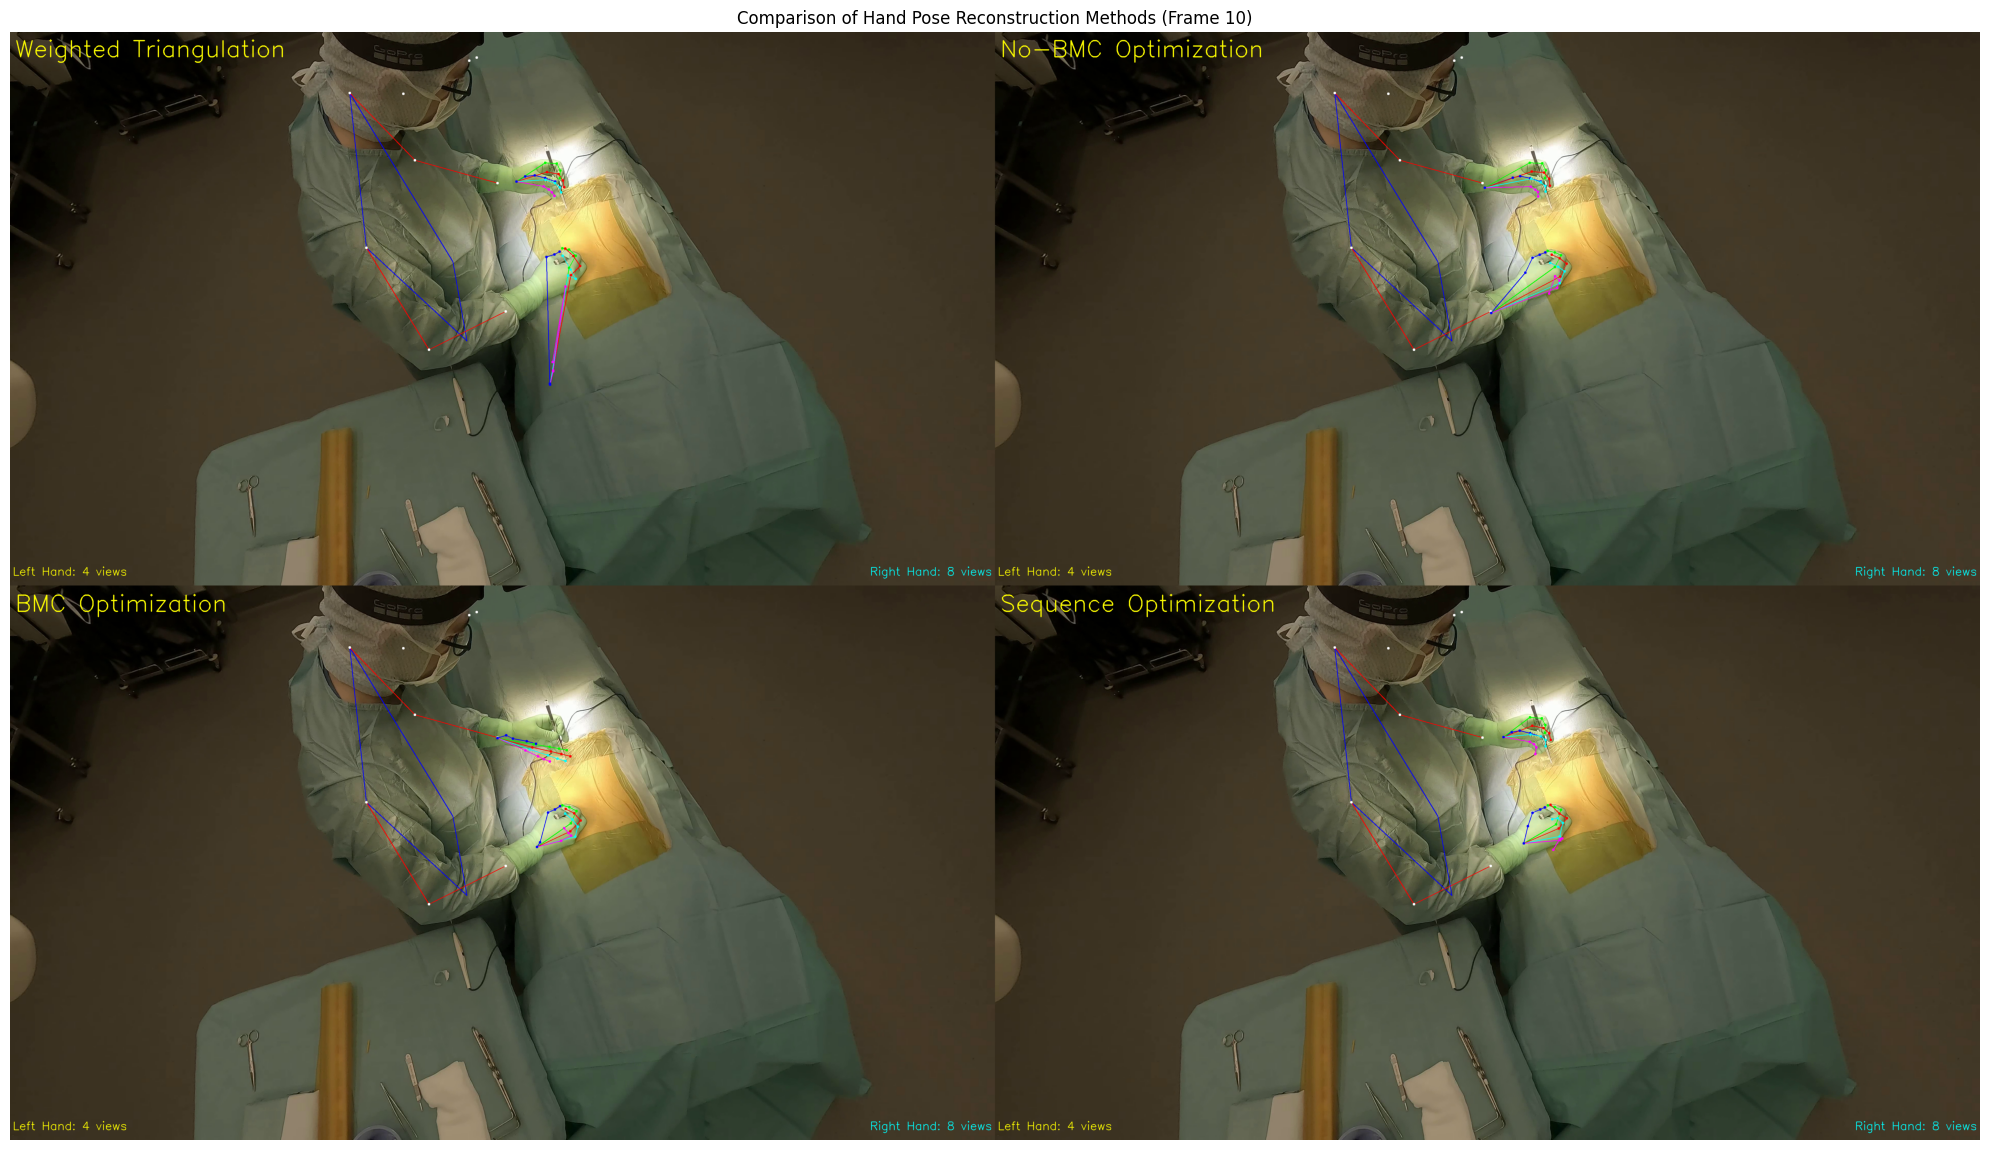

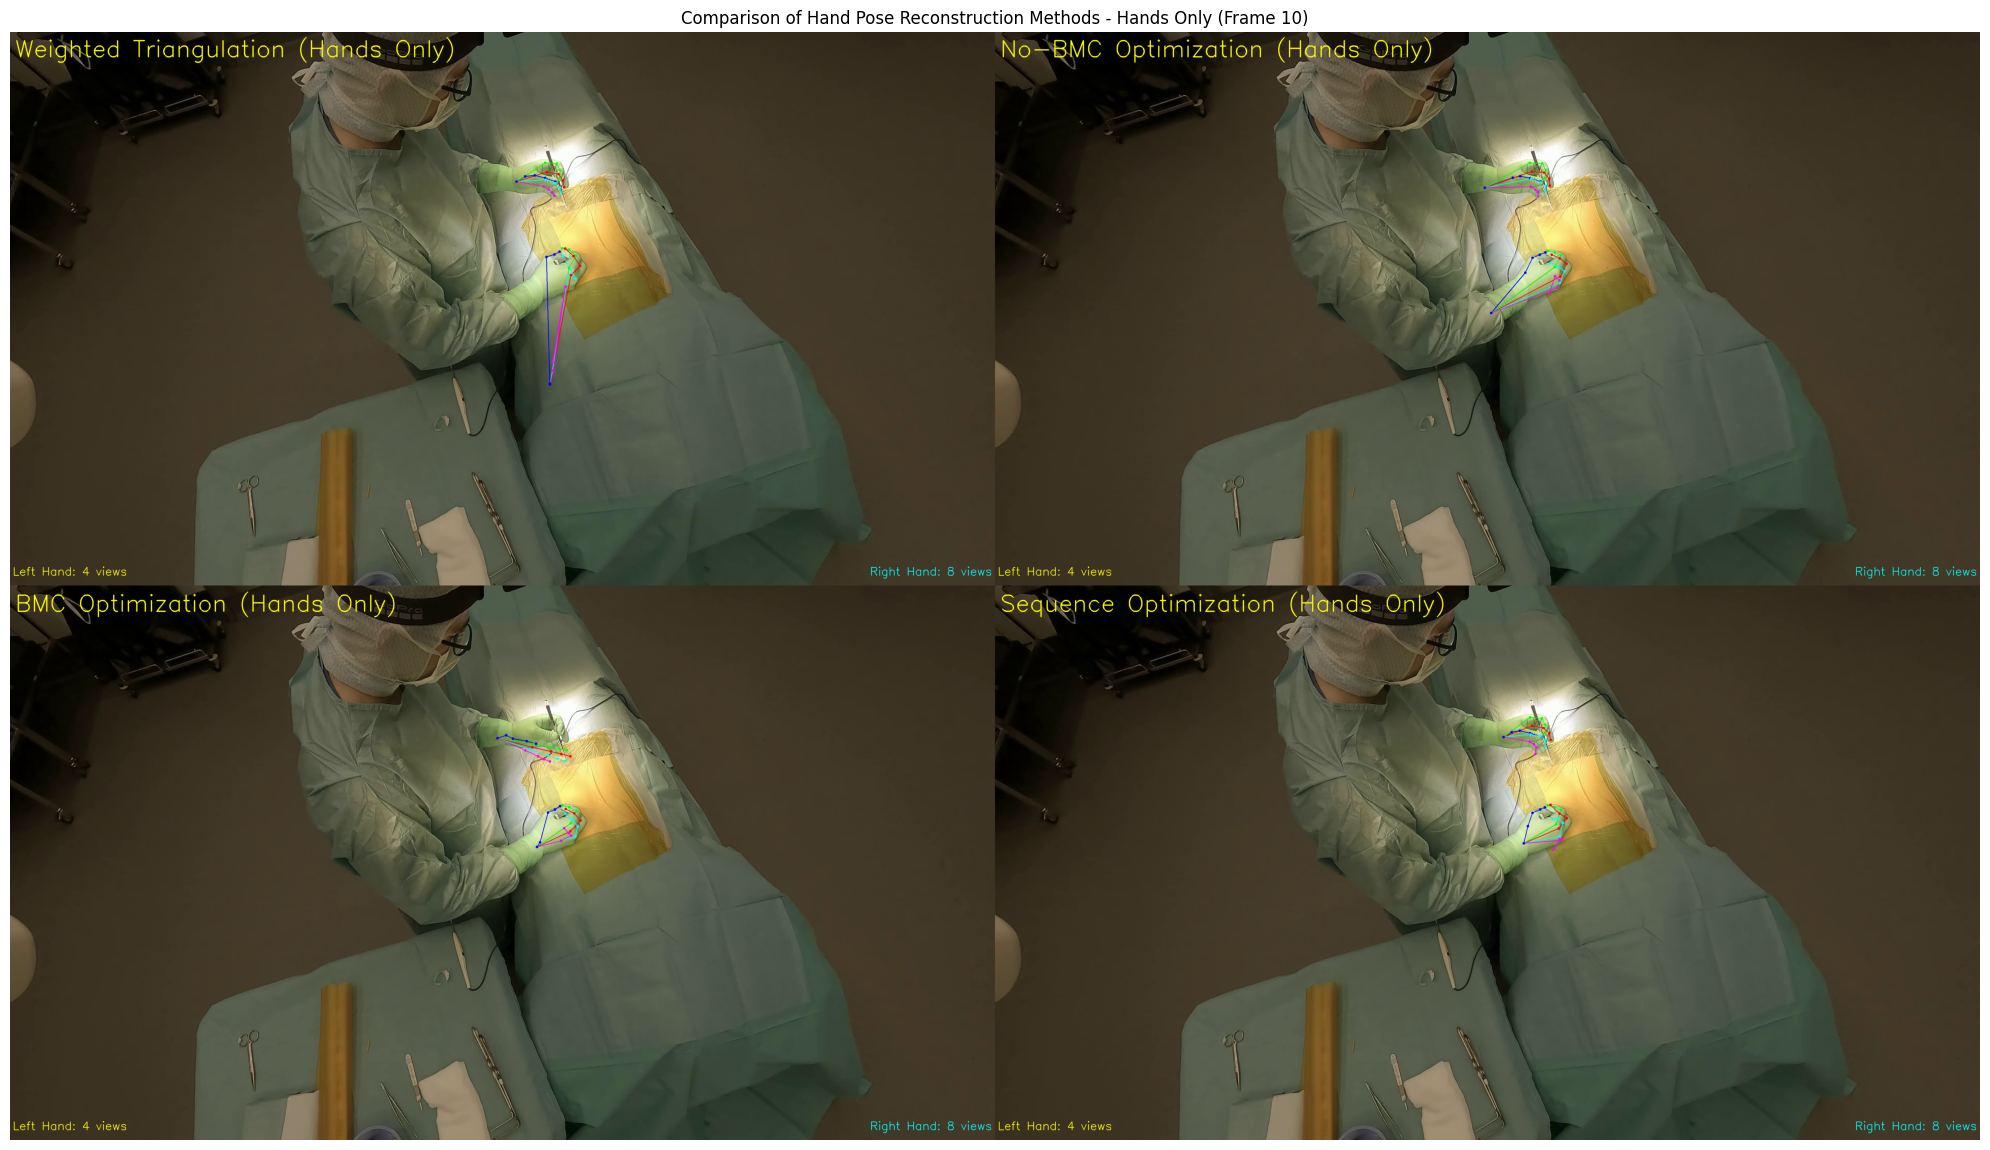

Quantitative Evaluation of Hand Pose Reconstruction Methods:
--------------------------------------------------------------------------------
Method                    Reprojection Error (px)   Temporal Smoothness      
--------------------------------------------------------------------------------
Triangulation             52.56                     0.0132                   
No-BMC Optimization       8.35                      0.0008                   
BMC Optimization          32.40                     0.0650                   
Sequence Optimization     9.16                      0.0044                   
--------------------------------------------------------------------------------
Notes:
- Lower reprojection error means better alignment with 2D observations
- Lower temporal smoothness value means smoother motion (less jitter)


In [10]:
# Compare visualizations of the four methods on a sample frame
camera = 'gopro8'
frame_idx = 10  # Choose a frame for comparison

video_path = os.path.join(data_dir, f'{camera}_synced_cut.MP4')
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()

if ret:
    # Get camera parameters
    cam_intrinsics = camera_intrinsics[camera].reshape(3,3)
    cam_extrinsics = camera_extrinsics[camera]
    cam_distortion = distortion_coeffs[camera]
    
    # Create visualizations for each method with body pose
    frame_bmc = visualize_poses(frame.copy(), poses_3d_body[frame_idx], optimized_hand_poses_3d[frame_idx], 
                              hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                              cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_triang = visualize_poses(frame.copy(), poses_3d_body[frame_idx], smoothed_triangulated_hands[frame_idx], 
                                 hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                 cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_nobmc = visualize_poses(frame.copy(), poses_3d_body[frame_idx], nobmc_optimized_hand_poses_3d[frame_idx], 
                                hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_sequence = visualize_poses(frame.copy(), poses_3d_body[frame_idx], sequence_optimized_hand_poses_3d[frame_idx], 
                                   hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                   cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    # Create visualizations for each method with only hands (no body)
    frame_bmc_hands = visualize_poses(frame.copy(), None, optimized_hand_poses_3d[frame_idx], 
                                    hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                    cam_distortion, frame_idx, camera, draw_body=False, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_triang_hands = visualize_poses(frame.copy(), None, smoothed_triangulated_hands[frame_idx], 
                                       hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                       cam_distortion, frame_idx, camera, draw_body=False, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_nobmc_hands = visualize_poses(frame.copy(), None, nobmc_optimized_hand_poses_3d[frame_idx], 
                                      hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                      cam_distortion, frame_idx, camera, draw_body=False, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_sequence_hands = visualize_poses(frame.copy(), None, sequence_optimized_hand_poses_3d[frame_idx], 
                                         hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                         cam_distortion, frame_idx, camera, draw_body=False, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    # Add clear method labels to the frames
    label_params = {
        'fontFace': cv2.FONT_HERSHEY_SIMPLEX,
        'org': (20, 100),
        'fontScale': 3.0,
        'color': (0, 255, 255),  # Yellow
        'thickness': 3,
    }
    
    cv2.putText(frame_bmc, "BMC Optimization", **label_params)
    cv2.putText(frame_triang, "Weighted Triangulation", **label_params)
    cv2.putText(frame_nobmc, "No-BMC Optimization", **label_params)
    cv2.putText(frame_sequence, "Sequence Optimization", **label_params)
    
    cv2.putText(frame_bmc_hands, "BMC Optimization (Hands Only)", **label_params)
    cv2.putText(frame_triang_hands, "Weighted Triangulation (Hands Only)", **label_params)
    cv2.putText(frame_nobmc_hands, "No-BMC Optimization (Hands Only)", **label_params)
    cv2.putText(frame_sequence_hands, "Sequence Optimization (Hands Only)", **label_params)
    
    # Display comparison - full pose (body + hands) - now with 4 methods
    # We'll make a 2x2 grid
    top_row = np.hstack([frame_triang, frame_nobmc])
    bottom_row = np.hstack([frame_bmc, frame_sequence])
    comparison_full = np.vstack([top_row, bottom_row])
    
    # Display comparison - hands only - now with 4 methods
    # We'll make a 2x2 grid
    top_row_hands = np.hstack([frame_triang_hands, frame_nobmc_hands])
    bottom_row_hands = np.hstack([frame_bmc_hands, frame_sequence_hands])
    comparison_hands = np.vstack([top_row_hands, bottom_row_hands])
    
    # Save the comparisons
    plt.figure(figsize=(20, 20))
    plt.imshow(cv2.cvtColor(comparison_full, cv2.COLOR_BGR2RGB))
    plt.title(f"Comparison of Hand Pose Reconstruction Methods (Frame {frame_idx})")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'{camera}_{frame_idx}_hand_methods_comparison_full.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    plt.figure(figsize=(20, 20))
    plt.imshow(cv2.cvtColor(comparison_hands, cv2.COLOR_BGR2RGB))
    plt.title(f"Comparison of Hand Pose Reconstruction Methods - Hands Only (Frame {frame_idx})")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'{camera}_{frame_idx}_hand_methods_comparison_hands.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Also add a cell with evaluation metrics to compare the methods quantitatively
    # Calculate reprojection error for each method
    def calculate_reprojection_error(hand_poses_3d, frame_idx):
        total_error = 0
        total_points = 0
        
        for cam_name, hand_pose_2d in hand_poses_2d.items():
            if frame_idx >= len(hand_pose_2d) or not hand_pose_2d[frame_idx]:
                continue
            
            cam_intrinsics = camera_intrinsics[cam_name].reshape(3, 3)
            cam_extrinsics = camera_extrinsics[cam_name]
            cam_distortion = distortion_coeffs[cam_name]
            
            # Process each detected hand
            for obj_id, hand_data in hand_pose_2d[frame_idx].items():
                # Get the hand side (left=0, right=1) from mapping
                if hand_id_mapping and cam_name in hand_id_mapping and obj_id in hand_id_mapping[cam_name]:
                    hand_side = hand_id_mapping[cam_name][obj_id]
                    
                    # Project the 3D hand keypoints to 2D
                    if hand_side == 0:  # Left hand
                        proj_keypoints = project_points(
                            hand_poses_3d[frame_idx][:num_keypoints_hands], 
                            cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], cam_distortion
                        )
                    else:  # Right hand
                        proj_keypoints = project_points(
                            hand_poses_3d[frame_idx][num_keypoints_hands:], 
                            cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], cam_distortion
                        )
                    
                    # Calculate reprojection error
                    keypoints_2d = hand_data.keypoints.squeeze()
                    scores = hand_data.keypoint_scores.squeeze()
                    
                    valid_mask = scores > 0.3
                    if np.any(valid_mask):
                        errors = np.linalg.norm(
                            proj_keypoints[valid_mask] - keypoints_2d[valid_mask],
                            axis=1
                        )
                        total_error += np.sum(errors)
                        total_points += np.sum(valid_mask)
        
        return total_error / total_points if total_points > 0 else float('inf')
    
    # Calculate temporal smoothness (average acceleration magnitude)
    def calculate_temporal_smoothness(hand_poses_3d, window=5):
        if len(hand_poses_3d) < 3:
            return float('inf')
        
        total_accel = 0
        count = 0
        
        for i in range(1, len(hand_poses_3d) - 1):
            start_idx = max(0, i - window // 2)
            end_idx = min(len(hand_poses_3d), i + window // 2 + 1)
            
            if end_idx - start_idx < 3:
                continue
                
            # Calculate acceleration as second derivative
            velocities = hand_poses_3d[start_idx+1:end_idx] - hand_poses_3d[start_idx:end_idx-1]
            accelerations = velocities[1:] - velocities[:-1]
            
            # Average magnitude of acceleration
            accel_magnitudes = np.linalg.norm(accelerations.reshape(-1, 3), axis=1)
            total_accel += np.mean(accel_magnitudes)
            count += 1
        
        return total_accel / count if count > 0 else float('inf')
    
    # Evaluate the methods
    methods = {
        'Triangulation': smoothed_triangulated_hands,
        'No-BMC Optimization': nobmc_optimized_hand_poses_3d,
        'BMC Optimization': optimized_hand_poses_3d,
        'Sequence Optimization': sequence_optimized_hand_poses_3d
    }
    
    evaluation_results = {}
    
    for name, poses in methods.items():
        # Evaluate reprojection error on sample frame
        repr_error = calculate_reprojection_error(poses, frame_idx)
        
        # Evaluate temporal smoothness
        temp_smoothness = calculate_temporal_smoothness(poses)
        
        evaluation_results[name] = {
            'reprojection_error': repr_error,
            'temporal_smoothness': temp_smoothness
        }
    
    # Print evaluation results
    print("Quantitative Evaluation of Hand Pose Reconstruction Methods:")
    print("-" * 80)
    print(f"{'Method':<25} {'Reprojection Error (px)':<25} {'Temporal Smoothness':<25}")
    print("-" * 80)
    
    for name, metrics in evaluation_results.items():
        print(f"{name:<25} {metrics['reprojection_error']:<25.2f} {metrics['temporal_smoothness']:<25.4f}")
    
    print("-" * 80)
    print("Notes:")
    print("- Lower reprojection error means better alignment with 2D observations")
    print("- Lower temporal smoothness value means smoother motion (less jitter)")

## Ablation Studies

This section implements two ablation studies to evaluate the contribution of different components in the full pipeline:

1. **Wholebody Bboxes Method**: Uses bounding boxes extracted directly from the wholebody pose estimation (without EfficientTAM tracking) for hand pose estimation. This evaluates the contribution of the tracking component.

2. **Direct Wholebody Hand Poses Method**: Uses the 2D hand poses directly from the wholebody model for sequence optimization. This evaluates the contribution of the specialized hand pose estimation model.

Both methods use the same sequence optimization approach as the main pipeline for fair comparison.

Ablation study 1 (wholebody bboxes) results already found, loading...


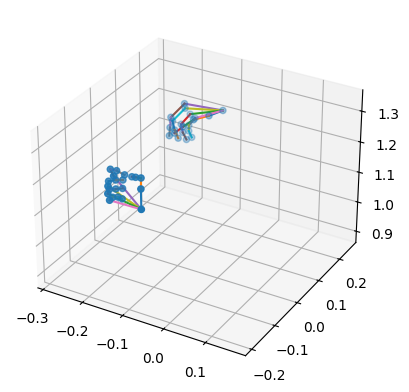

In [11]:
# Ablation Study 1: Using Wholebody Bboxes (without EfficientTAM tracking)
# This method uses bounding boxes extracted directly from the wholebody pose estimation
# and applies sequence optimization without the tracking component

if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_ablation_wholebody_bboxes.npz')):
    print("Ablation study 1 (wholebody bboxes) results already found, loading...")
    ablation_wholebody_bboxes_poses = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_ablation_wholebody_bboxes.npz'))['poses_3d']
    
else:
    print("Running Ablation Study 1: Using Wholebody Bboxes without EfficientTAM tracking...")
    
    # Extract hand poses using wholebody bboxes for each camera
    ablation_hand_poses_2d = {}
    
    for video_file in os.listdir(data_dir):
        if video_file.endswith('.MP4'):
            video_name = os.path.splitext(video_file)[0]
            if any(video_name.startswith(cam) for cam in near_field_cameras):
                cam_name = video_name.split('_')[0]
                print(f"Processing {video_name} for ablation study 1...")
                
                # Load wholebody pose data to extract hand bboxes
                wholebody_bbox_file = os.path.join(detection_dir, f"{video_name}.txt")
                if os.path.exists(wholebody_bbox_file):
                    detections = read_detection_file(wholebody_bbox_file, resolution, original_resolution, with_confidence=True, sort_by_confidence=False, confidence_threshold=0.3)
                    
                    # Extract hand bounding boxes from wholebody data
                    # This creates "tracks" similar to EfficientTAM but using wholebody detections
                    wholebody_tracks = {}

                    for frame_idx, bboxes in detections.items():
                        wholebody_tracks[frame_idx] = {}
                        # Create a track for each detected hand
                        for track_id, bbox in enumerate(bboxes):
                            wholebody_tracks[frame_idx][track_id] = bbox.astype(np.int64)                        
                    
                    # Convert to format similar to EfficientTAM tracks
                    video_path = os.path.join(data_dir, video_file)
                    
                    # Process poses using wholebody bboxes
                    if wholebody_tracks:
                        os.makedirs(os.path.join(pose_output_dir, 'ablation_wholebody_bboxes'), exist_ok=True)
                        print(f"Processing poses for {video_name} using wholebody bboxes...")
                        ablation_hand_poses_2d[cam_name] = process_and_visualize_poses(
                            video_path, 
                            wholebody_tracks, 
                            os.path.join(pose_output_dir, 'ablation_wholebody_bboxes'),
                            poses_3d_body,
                            camera_matrices,
                            camera_intrinsics,
                            camera_extrinsics,
                            distortion_coeffs,
                            hide_legs=True,
                            create_label_poses=False,  # Don't create labels for ablation study
                        )
    
    ablation_wholebody_bboxes_poses = []

    for frame_idx in range(len(poses_3d_body)):
        if frame_idx == 0:
            # For first frame, use initial hand poses
            initial_pose = np.concatenate([
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
                orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
            ])
            
            # Optimize without BMC but with hand ID mapping
            optimized_hand, loss = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs,
                frame_idx=frame_idx, hand_id_mapping=hand_id_mapping,
                lambdas=[1.0, 20.0, 50.0, 30.0], body_pose=poses_3d_body[frame_idx]
            )
            ablation_wholebody_bboxes_poses.append(optimized_hand)
            prev_optimized_hand = optimized_hand
        else:
            if adjust_hands:
                # Initialize hands based on previous optimized pose
                left_hand = initialize_hand_pose_for_next_frame(
                    prev_optimized_hand[:num_keypoints_hands], 
                    poses_3d_body[frame_idx], 
                    poses_3d_body[frame_idx-1], 
                    side='left'
                )
                right_hand = initialize_hand_pose_for_next_frame(
                    prev_optimized_hand[num_keypoints_hands:], 
                    poses_3d_body[frame_idx], 
                    poses_3d_body[frame_idx-1], 
                    side='right'
                )
            elif use_canonical:
                left_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
                right_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')

            else:
                left_hand = prev_optimized_hand[:num_keypoints_hands]
                right_hand = prev_optimized_hand[num_keypoints_hands:]

            # Concatenate left and right hand poses
            initial_pose = np.concatenate([left_hand, right_hand])
            
            # If the previous optimized hand is NaN, use the initial pose
            if np.isnan(prev_optimized_hand).any():
                print(f"Previous optimized hand for frame {frame_idx} is NaN, using initial pose")
                prev_optimized_hand = initial_pose

            # Optimize without BMC but with hand ID mapping
            optimized_hand, loss = optimize_poses_no_bmc(
                initial_pose, hand_poses_2d,
                camera_intrinsics, camera_extrinsics, distortion_coeffs,
                frame_idx=frame_idx, previous_pose=prev_optimized_hand,
                hand_id_mapping=hand_id_mapping, 
                lambdas=[1.0, 20.0, 50.0, 30.0], body_pose=poses_3d_body[frame_idx]
            )
            ablation_wholebody_bboxes_poses.append(optimized_hand)
            prev_optimized_hand = optimized_hand
            
        print(f"No-BMC optimized hand pose with mapping for frame {frame_idx}: {optimized_hand.shape}")

    ablation_wholebody_bboxes_poses = np.array(ablation_wholebody_bboxes_poses)

    
    # Save results
    output_file_ablation1 = os.path.join(output_3d_dir, 'hand_poses_3d_ablation_wholebody_bboxes.npz')
    np.savez(
        output_file_ablation1,
        poses_3d=ablation_wholebody_bboxes_poses,
    )
    
    print("Ablation Study 1 completed and saved.")

# Visualize ablation study 1 results
if not os.path.exists(os.path.join(output_3d_dir, 'visualization_ablation_wholebody_bboxes')):
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_ablation_wholebody_bboxes',
        ablation_wholebody_bboxes_poses,
        render_body=False,
        dynamic_limits=True
    )

Ablation study 2 (direct wholebody poses) results already found, loading...


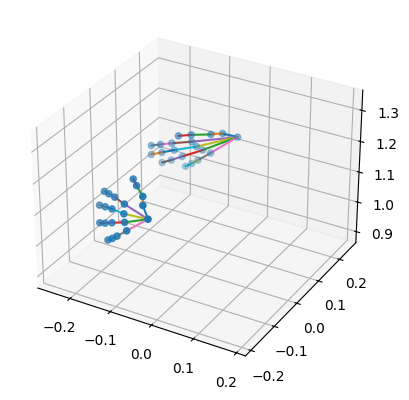

In [12]:
# Ablation Study 2: Using Direct Wholebody Hand Poses
# This method uses the 2D hand poses directly from the wholebody model
# for sequence optimization without specialized hand pose estimation

if not FORCE_RETRAIN and os.path.exists(os.path.join(output_3d_dir, 'hand_poses_3d_ablation_direct_wholebody.npz')):
    print("Ablation study 2 (direct wholebody poses) results already found, loading...")
    ablation_direct_wholebody_poses = np.load(os.path.join(output_3d_dir, 'hand_poses_3d_ablation_direct_wholebody.npz'))['poses_3d']
    
else:
    print("Running Ablation Study 2: Using Direct Wholebody Hand Poses...")
    
    # Extract hand poses directly from wholebody pose estimation
    direct_wholebody_hand_poses_2d = {}
    
    for video_file in os.listdir(data_dir):
        if video_file.endswith('.MP4'):
            video_name = os.path.splitext(video_file)[0]
            if any(video_name.startswith(cam) for cam in near_field_cameras):
                cam_name = video_name.split('_')[0]
                print(f"Processing {video_name} for ablation study 2...")
                
                # Load wholebody pose data
                wholebody_pose_file = os.path.join(pose_output_dir, f"{video_name}_wholebody_poses.json")
                if os.path.exists(wholebody_pose_file):
                    import json
                    with open(wholebody_pose_file, 'r') as f:
                        wholebody_data = json.load(f)
                    
                    # Extract hand poses directly from wholebody data
                    camera_hand_poses = []
                    
                    for frame_idx, frame_data in enumerate(wholebody_data):
                        frame_hands = {}
                        
                        if frame_data:  # If there are detections in this frame
                            for person_idx, person_data in enumerate(frame_data):
                                # Extract left hand keypoints (21 keypoints * 3 coordinates)
                                left_hand_start = 91  # Left hand starts at index 91 in wholebody format
                                left_hand_keypoints = []
                                left_hand_scores = []
                                
                                for i in range(21):  # 21 hand keypoints
                                    kp_idx = left_hand_start + i * 3
                                    if kp_idx + 2 < len(person_data['keypoints']):
                                        left_hand_keypoints.append([
                                            person_data['keypoints'][kp_idx],
                                            person_data['keypoints'][kp_idx + 1]
                                        ])
                                        left_hand_scores.append(person_data['keypoints'][kp_idx + 2])
                                    else:
                                        left_hand_keypoints.append([0, 0])
                                        left_hand_scores.append(0)
                                
                                # Extract right hand keypoints
                                right_hand_start = 112  # Right hand starts at index 112 in wholebody format
                                right_hand_keypoints = []
                                right_hand_scores = []
                                
                                for i in range(21):  # 21 hand keypoints
                                    kp_idx = right_hand_start + i * 3
                                    if kp_idx + 2 < len(person_data['keypoints']):
                                        right_hand_keypoints.append([
                                            person_data['keypoints'][kp_idx],
                                            person_data['keypoints'][kp_idx + 1]
                                        ])
                                        right_hand_scores.append(person_data['keypoints'][kp_idx + 2])
                                    else:
                                        right_hand_keypoints.append([0, 0])
                                        right_hand_scores.append(0)
                                
                                # Create hand data objects similar to the main pipeline
                                # Object ID 0 for left hand, 1 for right hand for each person
                                left_obj_id = person_idx * 2
                                right_obj_id = person_idx * 2 + 1
                                
                                # Only add hands with sufficient valid keypoints
                                if sum(s > 0.3 for s in left_hand_scores) > 5:
                                    # Create a simple object to hold hand data
                                    class HandData:
                                        def __init__(self, keypoints, scores):
                                            self.keypoints = np.array(keypoints).reshape(1, -1, 2)
                                            self.keypoint_scores = np.array(scores).reshape(1, -1)
                                    
                                    frame_hands[left_obj_id] = HandData(left_hand_keypoints, left_hand_scores)
                                
                                if sum(s > 0.3 for s in right_hand_scores) > 5:
                                    frame_hands[right_obj_id] = HandData(right_hand_keypoints, right_hand_scores)
                        
                        camera_hand_poses.append(frame_hands)
                    
                    direct_wholebody_hand_poses_2d[cam_name] = camera_hand_poses
    
    # Create hand ID mapping for direct wholebody poses
    direct_wholebody_hand_id_mapping = {}
    for cam_name in direct_wholebody_hand_poses_2d.keys():
        direct_wholebody_hand_id_mapping[cam_name] = {}
        # Map object IDs to hand sides based on wholebody detection
        for person_idx in range(2):  # Assuming max 2 people
            left_obj_id = person_idx * 2
            right_obj_id = person_idx * 2 + 1
            direct_wholebody_hand_id_mapping[cam_name][left_obj_id] = 0  # Left hand
            direct_wholebody_hand_id_mapping[cam_name][right_obj_id] = 1  # Right hand
    
    # Create initial poses for sequence optimization
    initial_sequence_ablation2 = []
    for frame_idx in range(len(poses_3d_body)):
        initial_pose = np.concatenate([
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left'),
            orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
        ])
        initial_sequence_ablation2.append(initial_pose)
    
    initial_sequence_ablation2 = np.array(initial_sequence_ablation2)
    initial_sequence_ablation2 = interpolate_keypoints(initial_sequence_ablation2)
    
    # Apply sequence optimization using direct wholebody hand poses
    print("Starting sequence optimization for ablation study 2...")
    ablation_direct_wholebody_poses = optimize_sequence(
        initial_sequence_ablation2,
        direct_wholebody_hand_poses_2d,
        camera_intrinsics,
        camera_extrinsics,
        distortion_coeffs,
        poses_3d_body,
        hand_id_mapping=direct_wholebody_hand_id_mapping,
        use_bmc=False,  # Use same settings as main sequence optimization
        lambdas=[1.0, 20.0, 20.0, 1.0, 5.0],  # [reprojection, temporal, spatial, bmc, shape]
    )
    
    # Save results
    output_file_ablation2 = os.path.join(output_3d_dir, 'hand_poses_3d_ablation_direct_wholebody.npz')
    np.savez(
        output_file_ablation2,
        poses_3d=ablation_direct_wholebody_poses,
    )
    
    print("Ablation Study 2 completed and saved.")

# Visualize ablation study 2 results
if not os.path.exists(os.path.join(output_3d_dir, 'visualization_ablation_direct_wholebody')):
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization_ablation_direct_wholebody',
        ablation_direct_wholebody_poses,
        render_body=False,
        dynamic_limits=True
    )

In [13]:
# Ablation Studies Comparison and Evaluation
# Compare the ablation study results with the main pipeline methods

# Create extended methods dictionary including ablation studies
hand_poses_methods_extended = {
    'Triangulation': smoothed_triangulated_hands,
    'No-BMC_Optimization': nobmc_optimized_hand_poses_3d,
    'BMC_Optimization': optimized_hand_poses_3d,
    'Sequence_Optimization': sequence_optimized_hand_poses_3d,
    'Ablation_Wholebody_Bboxes': ablation_wholebody_bboxes_poses,
    'Ablation_Direct_Wholebody': ablation_direct_wholebody_poses
}

# Create reprojection videos comparing all methods including ablation studies
create_reprojection_videos(
    poses_3d_body,
    hand_poses_methods_extended,
    camera_intrinsics,
    camera_extrinsics,
    distortion_coeffs,
    data_dir,
    os.path.join(output_3d_dir, 'ablation_comparisons'),
    camera_angles=['gopro10', 'gopro8', 'gopro7'],  # Specify which cameras to use
    hide_legs=True
)

# Quantitative evaluation of ablation studies
def evaluate_ablation_methods(hand_poses_methods, frame_idx=10):
    """Evaluate ablation methods quantitatively."""
    
    # Calculate reprojection error for each method
    def calculate_reprojection_error(hand_poses_3d, frame_idx):
        total_error = 0
        total_points = 0
        
        for cam_name, hand_pose_2d in hand_poses_2d.items():
            if frame_idx >= len(hand_pose_2d) or not hand_pose_2d[frame_idx]:
                continue
            
            cam_intrinsics = camera_intrinsics[cam_name].reshape(3, 3)
            cam_extrinsics = camera_extrinsics[cam_name]
            cam_distortion = distortion_coeffs[cam_name]
            
            # Process each detected hand
            for obj_id, hand_data in hand_pose_2d[frame_idx].items():
                # Get the hand side (left=0, right=1) from mapping
                if hand_id_mapping and cam_name in hand_id_mapping and obj_id in hand_id_mapping[cam_name]:
                    hand_side = hand_id_mapping[cam_name][obj_id]
                    
                    # Project the 3D hand keypoints to 2D
                    if hand_side == 0:  # Left hand
                        proj_keypoints = project_points(
                            hand_poses_3d[frame_idx][:num_keypoints_hands], 
                            cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], cam_distortion
                        )
                    else:  # Right hand
                        proj_keypoints = project_points(
                            hand_poses_3d[frame_idx][num_keypoints_hands:], 
                            cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], cam_distortion
                        )
                    
                    # Calculate reprojection error
                    keypoints_2d = hand_data.keypoints.squeeze()
                    scores = hand_data.keypoint_scores.squeeze()
                    
                    valid_mask = scores > 0.3
                    if np.any(valid_mask):
                        errors = np.linalg.norm(
                            proj_keypoints[valid_mask] - keypoints_2d[valid_mask],
                            axis=1
                        )
                        total_error += np.sum(errors)
                        total_points += np.sum(valid_mask)
        
        return total_error / total_points if total_points > 0 else float('inf')
    
    # Calculate temporal smoothness (average acceleration magnitude)
    def calculate_temporal_smoothness(hand_poses_3d, window=5):
        if len(hand_poses_3d) < 3:
            return float('inf')
        
        total_accel = 0
        count = 0
        
        for i in range(1, len(hand_poses_3d) - 1):
            start_idx = max(0, i - window // 2)
            end_idx = min(len(hand_poses_3d), i + window // 2 + 1)
            
            if end_idx - start_idx < 3:
                continue
                
            # Calculate acceleration as second derivative
            velocities = hand_poses_3d[start_idx+1:end_idx] - hand_poses_3d[start_idx:end_idx-1]
            accelerations = velocities[1:] - velocities[:-1]
            
            # Average magnitude of acceleration
            accel_magnitudes = np.linalg.norm(accelerations.reshape(-1, 3), axis=1)
            total_accel += np.mean(accel_magnitudes)
            count += 1
        
        return total_accel / count if count > 0 else float('inf')
    
    # Evaluate the methods
    evaluation_results = {}
    
    for name, poses in hand_poses_methods.items():
        # Evaluate reprojection error on sample frame
        repr_error = calculate_reprojection_error(poses, frame_idx)
        
        # Evaluate temporal smoothness
        temp_smoothness = calculate_temporal_smoothness(poses)
        
        evaluation_results[name] = {
            'reprojection_error': repr_error,
            'temporal_smoothness': temp_smoothness
        }
    
    return evaluation_results

# Run evaluation
ablation_evaluation_results = evaluate_ablation_methods(hand_poses_methods_extended)

# Print evaluation results
print("Quantitative Evaluation Including Ablation Studies:")
print("-" * 90)
print(f"{'Method':<30} {'Reprojection Error (px)':<25} {'Temporal Smoothness':<25}")
print("-" * 90)

for name, metrics in ablation_evaluation_results.items():
    print(f"{name:<30} {metrics['reprojection_error']:<25.2f} {metrics['temporal_smoothness']:<25.4f}")

print("-" * 90)
print("Ablation Study Analysis:")
print("- Ablation_Wholebody_Bboxes: Tests impact of EfficientTAM tracking")
print("- Ablation_Direct_Wholebody: Tests impact of specialized hand pose estimation")
print("- Lower reprojection error means better alignment with 2D observations")
print("- Lower temporal smoothness value means smoother motion (less jitter)")

# Create a visual comparison for ablation studies
camera = 'gopro8'
frame_idx = 10  # Choose a frame for comparison

video_path = os.path.join(data_dir, f'{camera}_synced_cut.MP4')
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()

if ret:
    # Get camera parameters
    cam_intrinsics = camera_intrinsics[camera].reshape(3,3)
    cam_extrinsics = camera_extrinsics[camera]
    cam_distortion = distortion_coeffs[camera]
    
    # Create visualizations for ablation study methods
    frame_ablation1 = visualize_poses(frame.copy(), poses_3d_body[frame_idx], ablation_wholebody_bboxes_poses[frame_idx], 
                                    hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                    cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_ablation2 = visualize_poses(frame.copy(), poses_3d_body[frame_idx], ablation_direct_wholebody_poses[frame_idx], 
                                    hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                    cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    frame_sequence = visualize_poses(frame.copy(), poses_3d_body[frame_idx], sequence_optimized_hand_poses_3d[frame_idx], 
                                   hand_poses_2d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], 
                                   cam_distortion, frame_idx, camera, hide_legs=True, hand_id_mapping=hand_id_mapping)
    
    # Add method labels
    label_params = {
        'fontFace': cv2.FONT_HERSHEY_SIMPLEX,
        'org': (20, 100),
        'fontScale': 2.0,
        'color': (0, 255, 255),  # Yellow
        'thickness': 2,
    }
    
    cv2.putText(frame_ablation1, "Ablation: Wholebody Bboxes", **label_params)
    cv2.putText(frame_ablation2, "Ablation: Direct Wholebody", **label_params)
    cv2.putText(frame_sequence, "Full Pipeline (Sequence Opt)", **label_params)
    
    # Create comparison image
    ablation_comparison = np.hstack([frame_sequence, frame_ablation1, frame_ablation2])
    
    # Display comparison
    plt.figure(figsize=(24, 8))
    plt.imshow(cv2.cvtColor(ablation_comparison, cv2.COLOR_BGR2RGB))
    plt.title(f"Ablation Studies Comparison (Frame {frame_idx})")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'{camera}_{frame_idx}_ablation_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Save all results summary
ablation_summary = {
    'methods': list(hand_poses_methods_extended.keys()),
    'evaluation_results': ablation_evaluation_results,
    'frame_evaluated': frame_idx
}

with open(os.path.join(output_3d_dir, 'ablation_study_summary.json'), 'w') as f:
    json.dump(ablation_summary, f, indent=2)

Processing frame 49/300 for camera gopro10

KeyboardInterrupt: 

## Sequence Optimization Benefits

The sequence optimization approach offers several advantages over frame-by-frame optimization:

1. **Improved Temporal Consistency**: By optimizing the entire sequence at once, this method can maintain smoother motion between frames

2. **Global Constraints**: The method can enforce global constraints across the entire sequence, rather than just between consecutive frames

3. **Reduced Jitter**: The method typically produces less jitter than other approaches, especially in cases with occlusions

4. **Parameter Sharing**: Information from well-observed frames can help refine poses in frames with poor observations

The sequence optimization can be run with or without BMC constraints, allowing for flexibility in the biomechanical plausibility of the results.

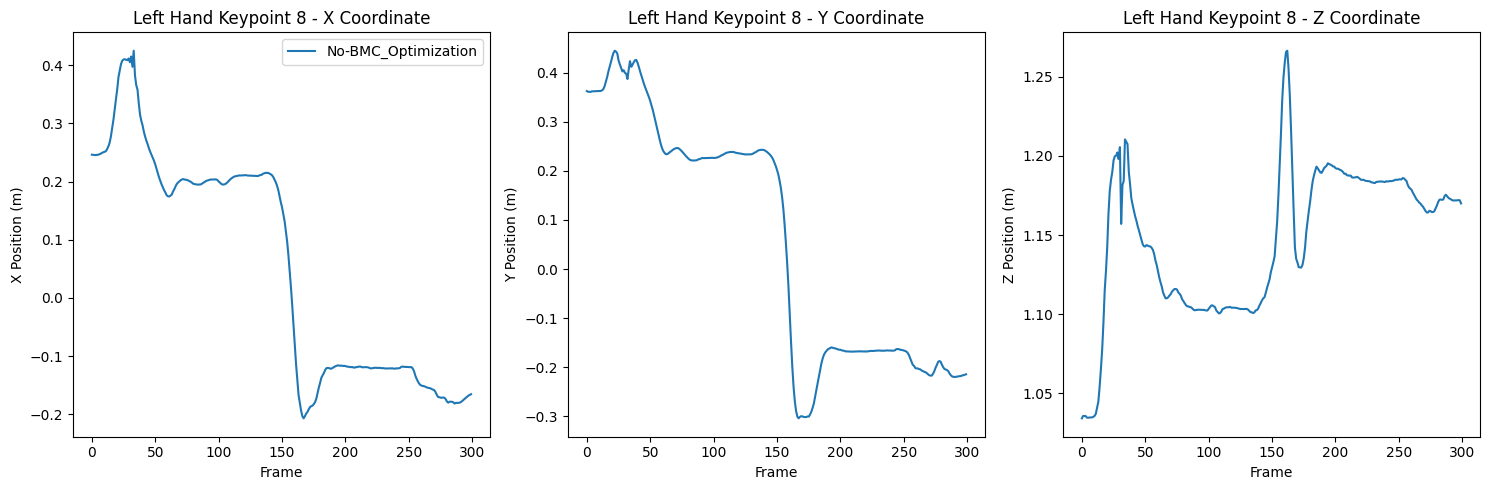

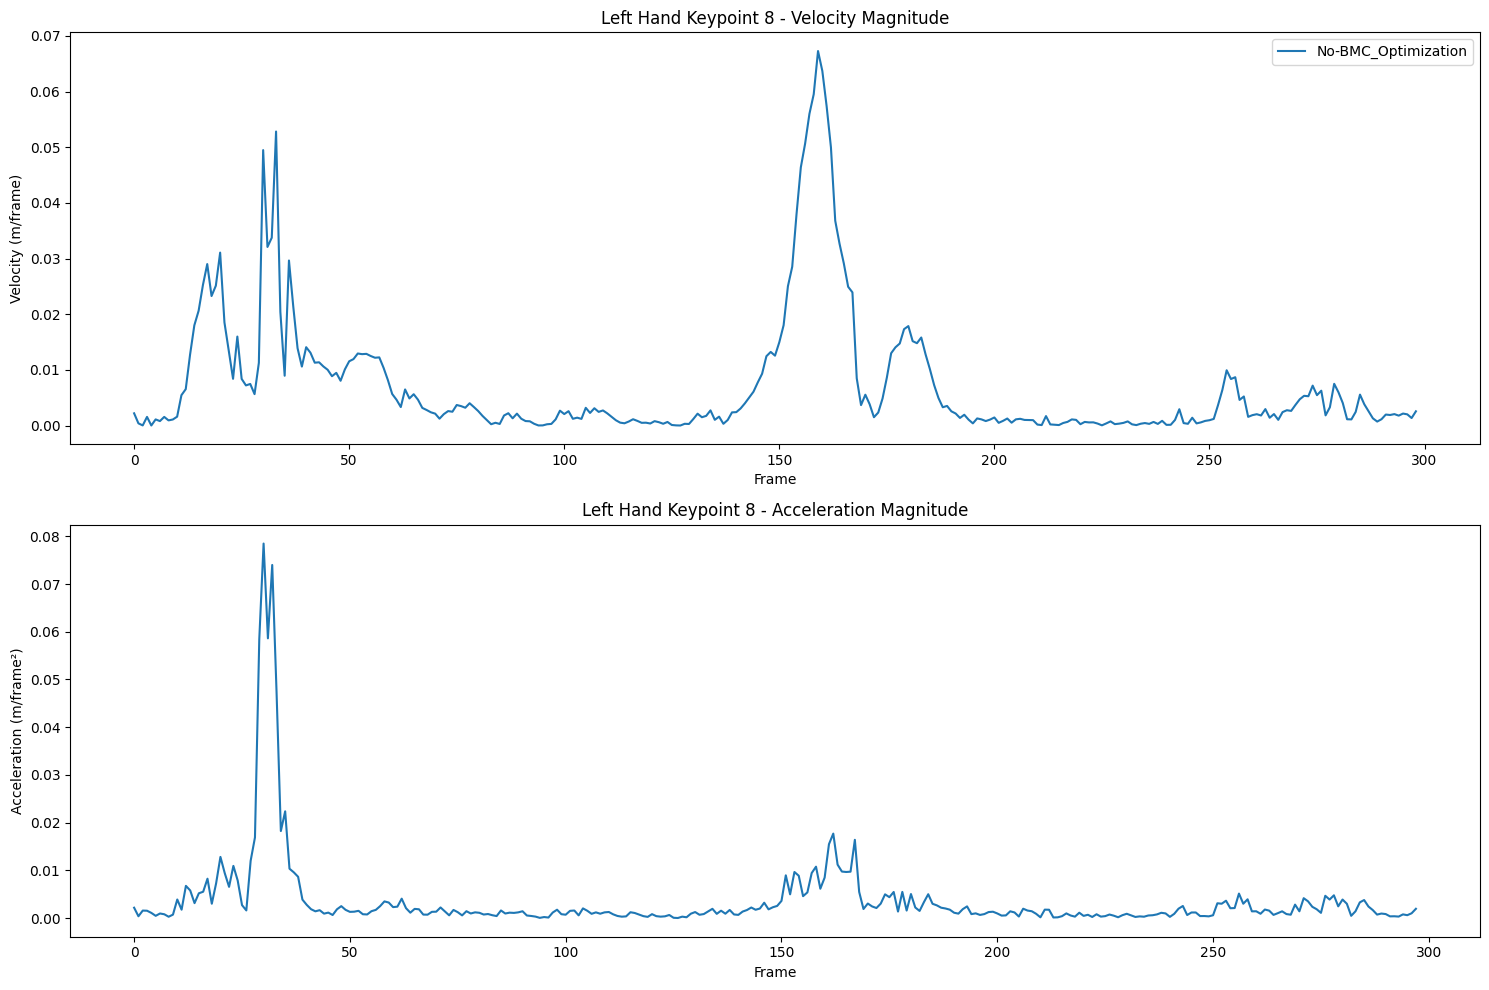

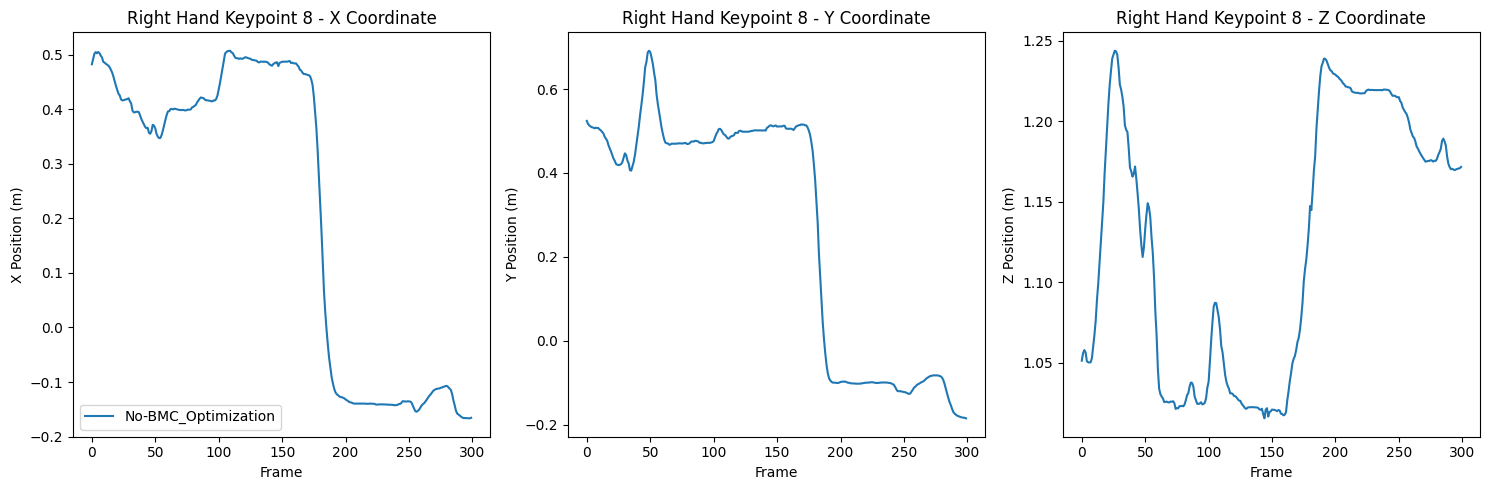

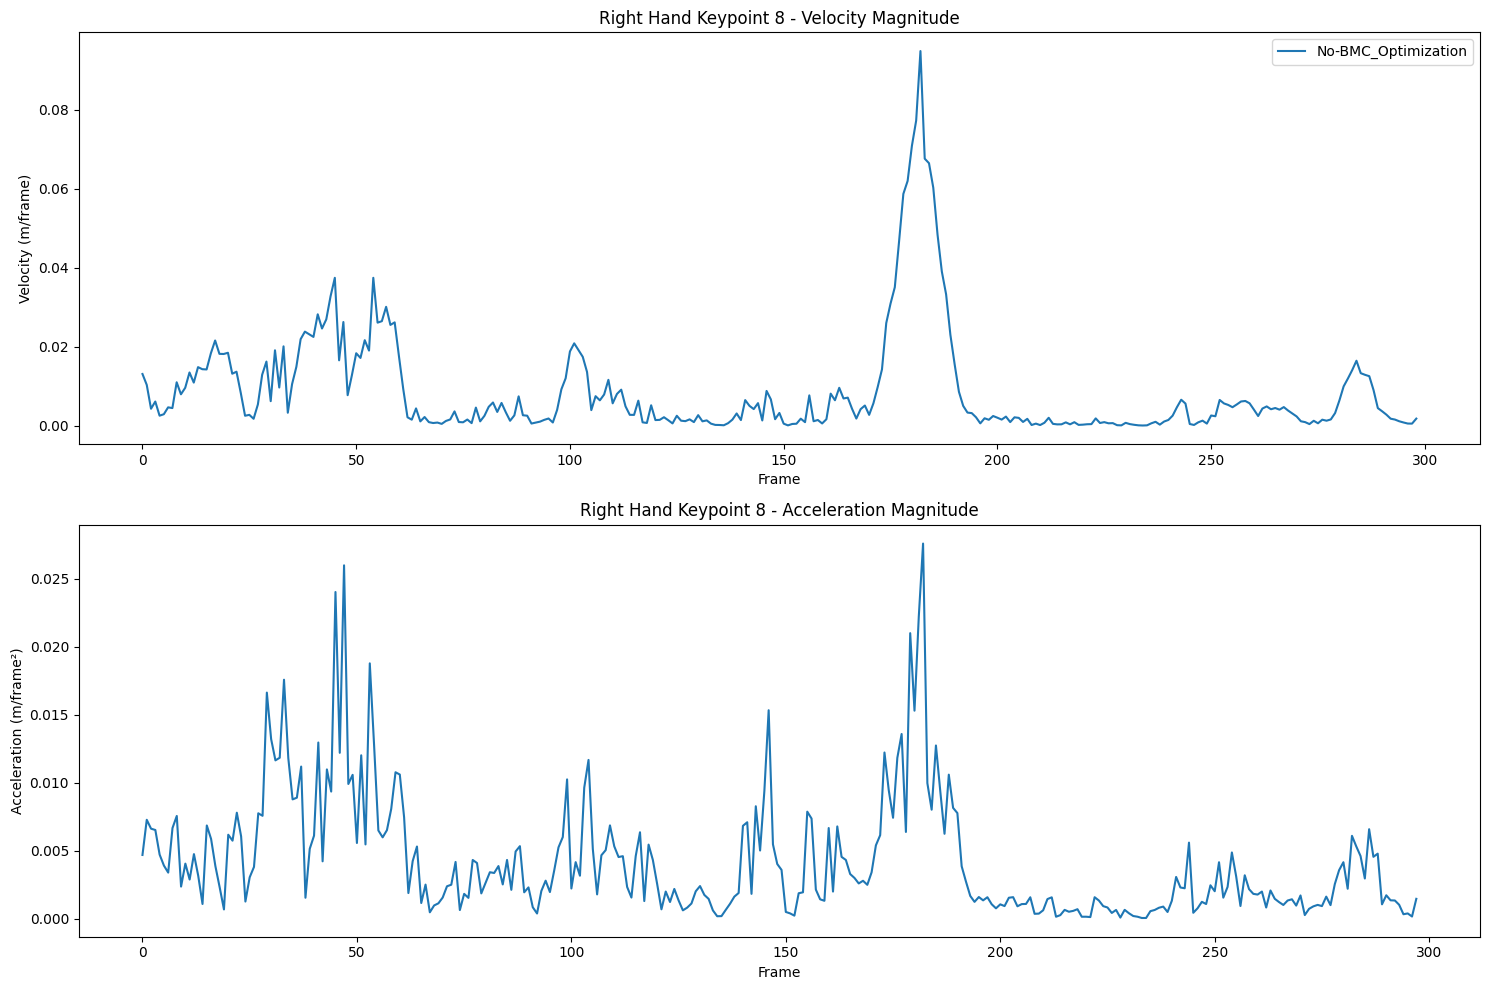

In [ ]:
# Advanced analysis of sequence optimization

# Plot trajectory smoothness comparison for a specific keypoint
def plot_keypoint_trajectory(hand_poses_methods_mapped, keypoint_idx=8, hand_side='left'):
    """Plot the 3D trajectory of a specific keypoint across methods."""
    plt.figure(figsize=(15, 5))
    
    # Set up which hand and keypoint to analyze
    if hand_side == 'left':
        kp_idx = keypoint_idx
    else:
        kp_idx = num_keypoints_hands + keypoint_idx
    
    # Plot X coordinate over time
    plt.subplot(1, 3, 1)
    for method_name, poses in hand_poses_methods_mapped.items():
        x_coords = poses[:, kp_idx, 0]
        plt.plot(x_coords, label=method_name)
    plt.title(f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - X Coordinate')
    plt.xlabel('Frame')
    plt.ylabel('X Position (m)')
    plt.legend()
    
    # Plot Y coordinate over time
    plt.subplot(1, 3, 2)
    for method_name, poses in hand_poses_methods_mapped.items():
        y_coords = poses[:, kp_idx, 1]
        plt.plot(y_coords, label=method_name)
    plt.title(f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - Y Coordinate')
    plt.xlabel('Frame')
    plt.ylabel('Y Position (m)')
    
    # Plot Z coordinate over time
    plt.subplot(1, 3, 3)
    for method_name, poses in hand_poses_methods_mapped.items():
        z_coords = poses[:, kp_idx, 2]
        plt.plot(z_coords, label=method_name)
    plt.title(f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - Z Coordinate')
    plt.xlabel('Frame')
    plt.ylabel('Z Position (m)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'keypoint_{keypoint_idx}_{hand_side}_trajectory_comparison.png'), dpi=300)
    plt.show()

# Calculate velocity and acceleration for each method
def plot_motion_derivatives(hand_poses_methods_mapped, keypoint_idx=8, hand_side='left'):
    """Plot velocity and acceleration profiles for each method."""
    plt.figure(figsize=(15, 10))
    
    # Set up which hand and keypoint to analyze
    if hand_side == 'left':
        kp_idx = keypoint_idx
    else:
        kp_idx = num_keypoints_hands + keypoint_idx
    
    # Plot velocity magnitude over time
    plt.subplot(2, 1, 1)
    for method_name, poses in hand_poses_methods_mapped.items():
        # Calculate velocity as first derivative of position
        velocities = np.linalg.norm(poses[1:, kp_idx] - poses[:-1, kp_idx], axis=1)
        plt.plot(velocities, label=method_name)
    plt.title(f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - Velocity Magnitude')
    plt.xlabel('Frame')
    plt.ylabel('Velocity (m/frame)')
    plt.legend()
    
    # Plot acceleration magnitude over time
    plt.subplot(2, 1, 2)
    for method_name, poses in hand_poses_methods_mapped.items():
        # Calculate velocity
        velocities = poses[1:, kp_idx] - poses[:-1, kp_idx]
        # Calculate acceleration as first derivative of velocity
        if len(velocities) > 1:
            accelerations = np.linalg.norm(velocities[1:] - velocities[:-1], axis=1)
            plt.plot(accelerations, label=method_name)
    plt.title(f'{hand_side.capitalize()} Hand Keypoint {keypoint_idx} - Acceleration Magnitude')
    plt.xlabel('Frame')
    plt.ylabel('Acceleration (m/frame²)')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_3d_dir, f'keypoint_{keypoint_idx}_{hand_side}_derivatives_comparison.png'), dpi=300)
    plt.show()

# Run the analysis for an index finger tip
keypoint_to_analyze = 8  # Index finger tip
plot_keypoint_trajectory(hand_poses_methods_mapped, keypoint_idx=keypoint_to_analyze, hand_side='left')
plot_motion_derivatives(hand_poses_methods_mapped, keypoint_idx=keypoint_to_analyze, hand_side='left')

# Also analyze the right hand
plot_keypoint_trajectory(hand_poses_methods_mapped, keypoint_idx=keypoint_to_analyze, hand_side='right')
plot_motion_derivatives(hand_poses_methods_mapped, keypoint_idx=keypoint_to_analyze, hand_side='right')